In [2]:
import pdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pylab as pylab
import cartopy
import cartopy.crs as ccrs
import pickle as pkl
import glob
from metpy import calc
from metpy.units import units
import matplotlib.patches as patches
from scipy import stats

from shared.paths import load_paths
paths = load_paths()

pylab.rcParams['figure.figsize'] = (50., 50.)
%matplotlib inline

In [1]:
cd ../..

/home/users/cornkle/pythonWorkspace/proj_CEH


In [3]:
def calc_div(da):
    u = units.Quantity(da['u_srfc'].values, 'm/s')
    v = units.Quantity(da['v_srfc'].values, 'm/s')
    
    dx = units.Quantity(4400, 'm')
    div = calc.divergence(u,v, dx=dx, dy=dx)
    # vort = calc.shearing_deformation(u,v, dx, dx)
    da_div = da['sh'].copy(deep=True)
    da_div.values = div
    
    return da_div

In [4]:
cp4_path = '/gws/ssde/j25b/lmcs/cklein/CP_models/MCS_files/WAf/CP4_box_JASMIN/mean3h_v2'

In [12]:
da_hist_anom = (xr.open_dataset(cp4_path + '/hist_anom_Jul-Sep_17h_2d.nc')+xr.open_dataset(cp4_path + '/hist_anom_Jul-Sep_18h_2d.nc'))/2
da_fut_anom = (xr.open_dataset(cp4_path + '/fut_anom_Jul-Sep_17h_2d.nc')+xr.open_dataset(cp4_path + '/fut_anom_Jul-Sep_18h_2d.nc'))/2

da_hist = (xr.open_dataset(cp4_path + '/hist_mean_Jul-Sep_17h_2d.nc')+xr.open_dataset(cp4_path + '/hist_mean_Jul-Sep_18h_2d.nc'))/2
da_fut = (xr.open_dataset(cp4_path + '/fut_mean_Jul-Sep_17h_2d.nc')+xr.open_dataset(cp4_path + '/fut_mean_Jul-Sep_18h_2d.nc'))/2

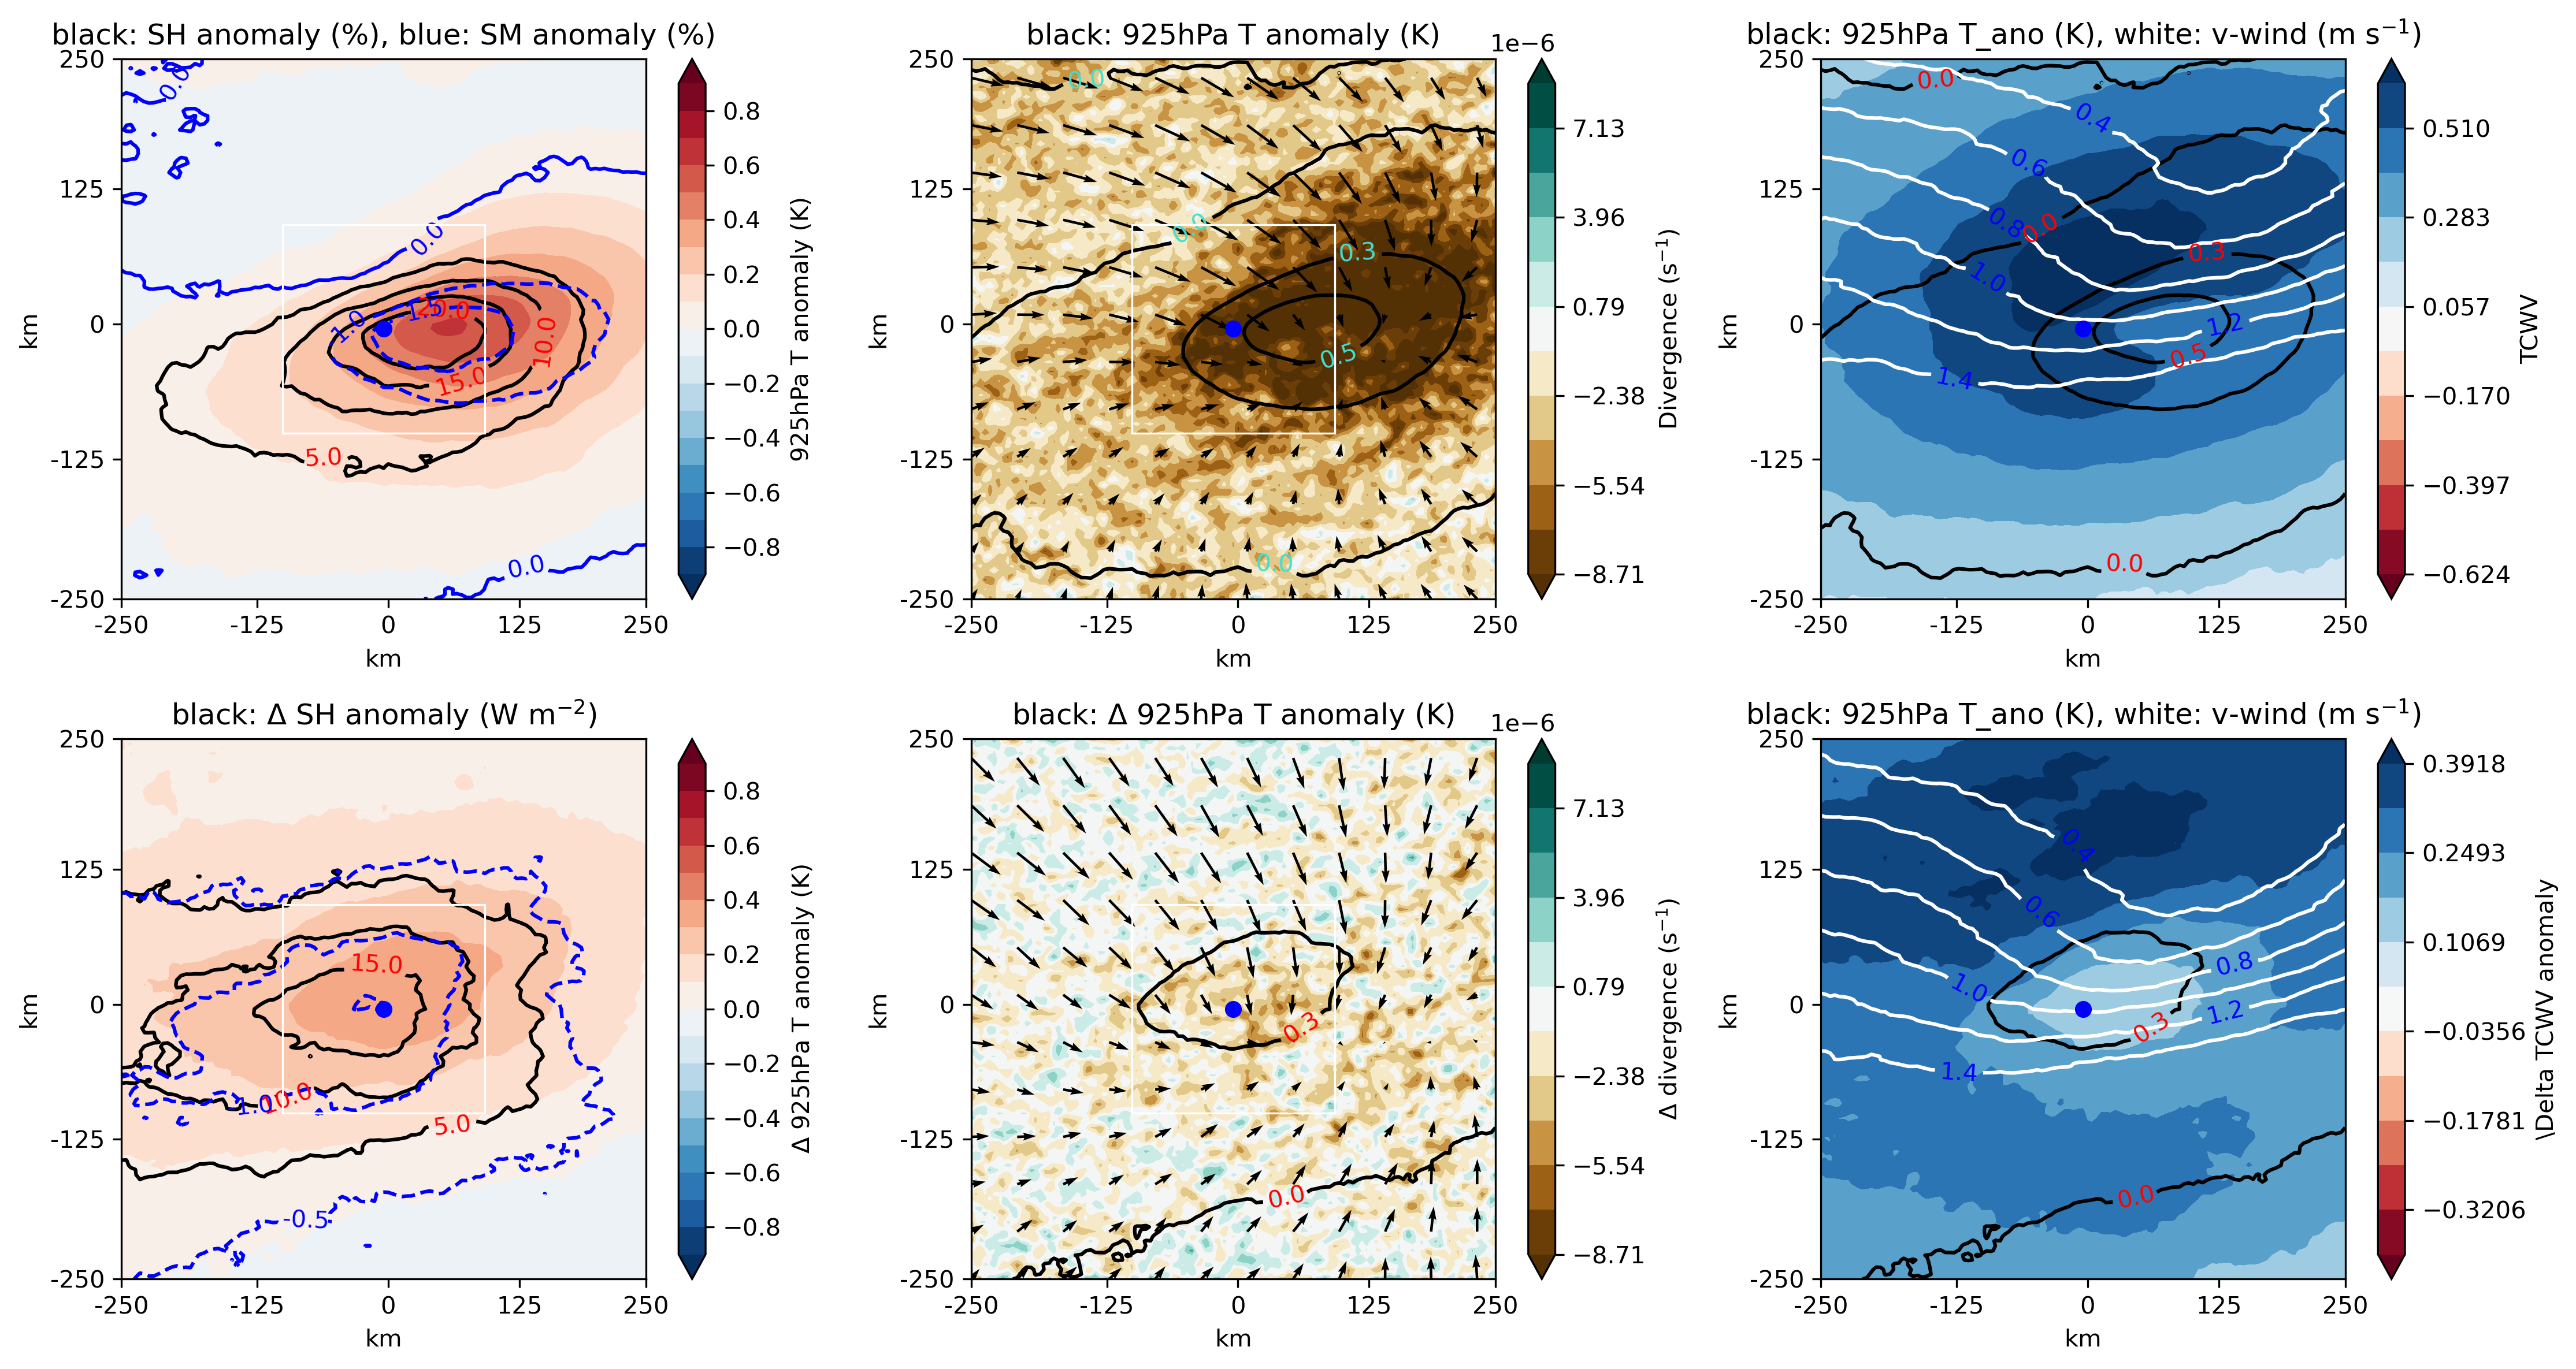

In [21]:
f = plt.figure(figsize=(15,8), dpi=300)
mname = 'node'
extent = 57 #* 4.4

ticks = np.array([0,58-57/2,58,58+57/2,114])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]
mid=57
dist = 22
box = [mid-dist, mid+dist,mid-dist, mid+dist]

ax = f.add_subplot(2,3,1)

#ano = da_hist_anom['t2']#.mean('cases')
cont =da_hist_anom['sh']
cont2 = da_hist_anom['SM']
ano = da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='925hPa T anomaly (K)')
plt.title('black: SH anomaly (%), blue: SM anomaly (%)')
cm = ax.contour(cont, colors='k', levels=[5,10,15,20], linewidths=1.5)  #
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cm = ax.contour(cont2, colors='blue', levels=[-1.5,-1,0,1,1.5], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

ax = f.add_subplot(2,3,2)
ano_div = calc_div(da_hist)
cont = da_hist_anom['t_srfc']


div_thresh = np.max(np.abs(np.percentile(ano_div, [10, 90])))

plt.contourf(ano_div, cmap='BrBG', extend='both', levels=np.linspace(div_thresh * -1, div_thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='Divergence (s$^{-1}$)')
plt.title('black: 925hPa T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_hist_anom['u_srfc'].values, da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



ax = f.add_subplot(2,3,3)
ano = da_hist_anom['q_srfc']*1000
cont = da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'TCWV')
plt.title('black: 925hPa T_ano (K), white: v-wind (m s$^{-1}$)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cont = da_hist['v_srfc']
cm = ax.contour(cont, colors='w', levels=[-1.4,-1.2,-1, -0.8, -0.6,-0.4,0,0.4,0.6,0.8,1,1.2,1.4], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='b')

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



###############################################

ax = f.add_subplot(2,3,4)

#ano = da_hist_anom['t2']#.mean('cases')
cont =(da_fut_anom['sh']-da_hist_anom['sh'])
cont2 = da_fut_anom['SM']-da_hist_anom['SM']

ano = da_fut_anom['t_srfc']-da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1))  #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'$\Delta$ 925hPa T anomaly (K)')
plt.title(r'black: $\Delta$ SH anomaly (W m$^{-2}$)')
cm = ax.contour(cont, colors='k', levels=[5,10,15], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cm = ax.contour(cont2, colors='blue', levels=[-1.5,-1,-0.5], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,5)

ano = calc_div(da_hist)
anofut = calc_div(da_fut)
ano = anofut-ano
cont = da_fut_anom['t_srfc']-da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano_div, [10, 90])))

plt.contourf(ano, cmap='BrBG', extend='both', levels=np.linspace(div_thresh * -1, div_thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'$\Delta$ divergence (s$^{-1}$)')
plt.title(r'black: $\Delta$ 925hPa T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9,-0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_fut_anom['u_srfc'].values-da_hist_anom['u_srfc'].values, da_fut_anom['v_srfc'].values-da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



ax = f.add_subplot(2,3,6)
ano =  (da_fut_anom['q_srfc']-da_hist_anom['q_srfc'])*1000
cont = (da_fut_anom['t_srfc']-da_hist_anom['t_srfc'])

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'\Delta TCWV anomaly')
plt.title('black: 925hPa T_ano (K), white: v-wind (m s$^{-1}$)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cont = da_fut['v_srfc']
cm = ax.contour(cont, colors='w', levels=[-1.4,-1.2,-1, -0.8, -0.6,-0.4,0,0.4,0.6,0.8,1,1.2,1.4], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='b')

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



plt.tight_layout()
f.savefig('cp4_2d_18h_gig1.jpg')